In [1]:
import os
import urllib.request
import zipfile
import tarfile
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import csv
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

print("PyTorch verzija: " + torch.__version__)

# Postavljanje uređaja (GPU ako je dostupan, inače CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Uređaj za treniranje: {device}")

PyTorch verzija: 2.10.0+cu128
Uređaj za treniranje: cuda:0


In [2]:
########################################################################################################################
# 1. MONTIRANJE GOOGLE DRIVE-A I PODEŠAVANJE PUTANJA
########################################################################################################################

from google.colab import drive
drive.mount('/content/drive')

drive_results_folder = '/content/drive/MyDrive/Caltech101_v2_Results_PyTorch'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)

Mounted at /content/drive


In [3]:
########################################################################################################################
# 2. PREUZIMANJE I RASPAKIVANJE PODATAKA
########################################################################################################################

dataset_url = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip"
zip_path = "/content/caltech-101.zip"
caltech_folder = "/content/caltech-101"
data_folder = "/content/101_ObjectCategories"

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(dataset_url, zip_path)

if not os.path.exists(caltech_folder):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists(data_folder):
    tar_path = os.path.join(caltech_folder, '101_ObjectCategories.tar.gz')
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall('/content/')

/tmp/ipykernel_3785/1836085986.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall('/content/')


In [4]:
########################################################################################################################
# 3. PODRŠKA ZA UČITAVANJE I AUGMENTACIJU PODATAKA
########################################################################################################################

def load_data_def():
    categories = []
    train_data = []
    test_data = []

    image_folders = sorted(os.listdir(data_folder))
    for c in image_folders:
        if c == 'BACKGROUND_Google':
            continue

        path = os.path.join(data_folder, c)
        if os.path.isdir(path):
            categories.append(c)
            cnt = 0
            files = sorted(os.listdir(path))
            for f in files:
                image_file = os.path.join(path, f)
                if os.path.isfile(image_file):
                    # Smeštamo tuple (putanja, indeks_klase)
                    if cnt % 5 == 2:
                        test_data.append((image_file, categories.index(c)))
                    else:
                        train_data.append((image_file, categories.index(c)))
                    cnt += 1

    # Nasumično mešanje lista putanja
    train_data = np.random.RandomState(seed=0).permutation(train_data).tolist()
    test_data = np.random.RandomState(seed=0).permutation(test_data).tolist()

    return categories, train_data, test_data

class CaltechDataset(Dataset):
    def __init__(self, data_list, image_size, transform=None, keep_aspect=True, fill_value=0):
        self.data_list = data_list
        self.image_size = image_size
        self.transform = transform
        self.keep_aspect = keep_aspect
        self.fill_value = fill_value

        self.base_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # 1. Učitavanje putanje i labele iz liste
        img_path, label = self.data_list[idx]

        # 2. Dinamičko učitavanje slike sa diska
        img = cv.imread(img_path)
        if img is None:
            # U slučaju greške, vraćamo crnu sliku
            img = np.zeros((self.image_size, self.image_size, 3), np.uint8)

        # 3. Obrada ivica (keep aspect ratio) - prebačeno ovde iz load_data
        if self.keep_aspect:
            cy, cx = img.shape[:2]
            if cx > cy:
                d = cx - cy
                img = cv.copyMakeBorder(img, top=d//2, bottom=d-d//2, left=0, right=0,
                                        borderType=cv.BORDER_CONSTANT, value=self.fill_value)
            else:
                d = cy - cx
                img = cv.copyMakeBorder(img, top=0, bottom=0, left=d//2, right=d-d//2,
                                        borderType=cv.BORDER_CONSTANT, value=self.fill_value)

        # 4. Promena veličine i konverzija boja
        img = cv.resize(img, (self.image_size, self.image_size), interpolation=cv.INTER_LINEAR)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        # 5. Augmentacija (ako je definisana)
        if self.transform:
            img = self.transform(img)

        # 6. Tensor konverzija i normalizacija
        img_tensor = self.base_transform(img)
        return img_tensor, torch.tensor(int(label), dtype=torch.long)

In [5]:
########################################################################################################################
# 4. FUNKCIJA ZA KREIRANJE MODELA
########################################################################################################################

def create_model(classes, trainable_encoder=False):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    if not trainable_encoder:
        # 1. Prvo zamrznemo sve parametre
        for param in model.parameters():
            param.requires_grad = False

        # 2. Zatim prođemo kroz sve module i ODMRZNEMO Batch Normalization (kao u Kerasu)
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                for param in module.parameters():
                    param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5, inplace=True),
        nn.Linear(in_features, classes)
    )

    return model

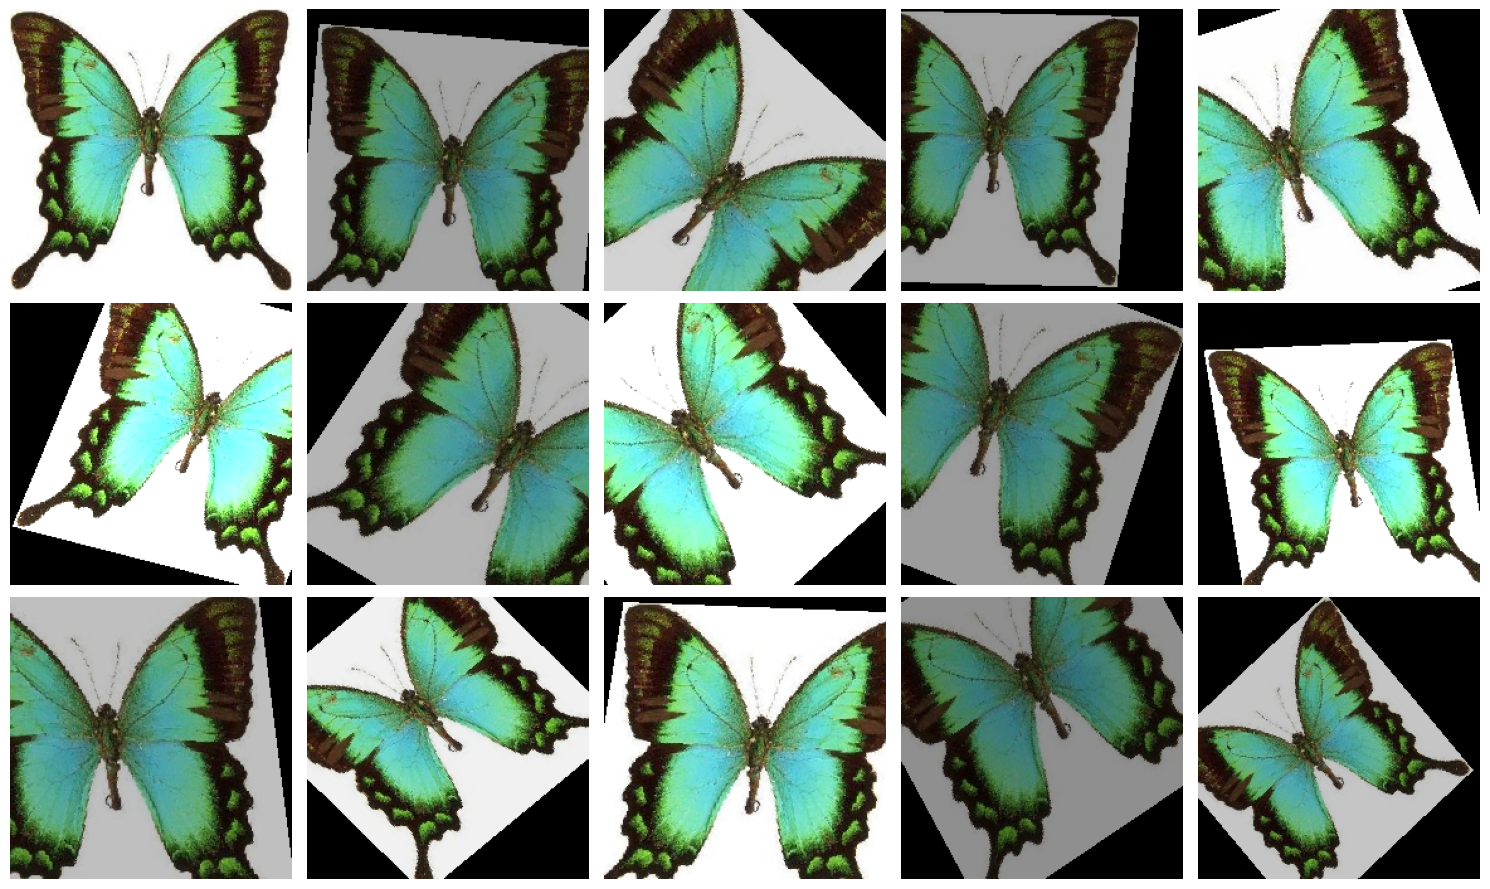

In [6]:
########################################################################################################################
# 5. DATA AUGMENTATION
########################################################################################################################

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=45, translate=(0.2, 0.2), scale=(0.8, 1.2), shear=10),
    transforms.ColorJitter(brightness=(0.5, 1.5))
])

# Test data augmentation
img = cv.imread(os.path.join(data_folder, 'butterfly', 'image_0018.jpg'))
img = cv.resize(img, (224, 224))
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(15, 9))  # Širina i visina prozora za prikaz

for i in range(15):
    if i == 0:
        img_da = img
    else:
        img_da = train_transforms(img)
    plt.subplot(3, 5, i + 1)  # Kreiranje grida: 3 reda, 5 kolona, i-ta pozicija
    plt.imshow(img_da)
    plt.axis('off')  # Isključivanje x i y osa radi preglednijeg prikaza slika

plt.tight_layout()  # Automatsko podešavanje razmaka između slika
plt.show()          # Prikaz grida u Colab ćeliji

Učitavanje i pretprocesiranje slika...
Broj trening slika: 6941
Broj test slika: 1736
Broj kategorija: 101

Prikaz prvih 10 slika iz test skupa...


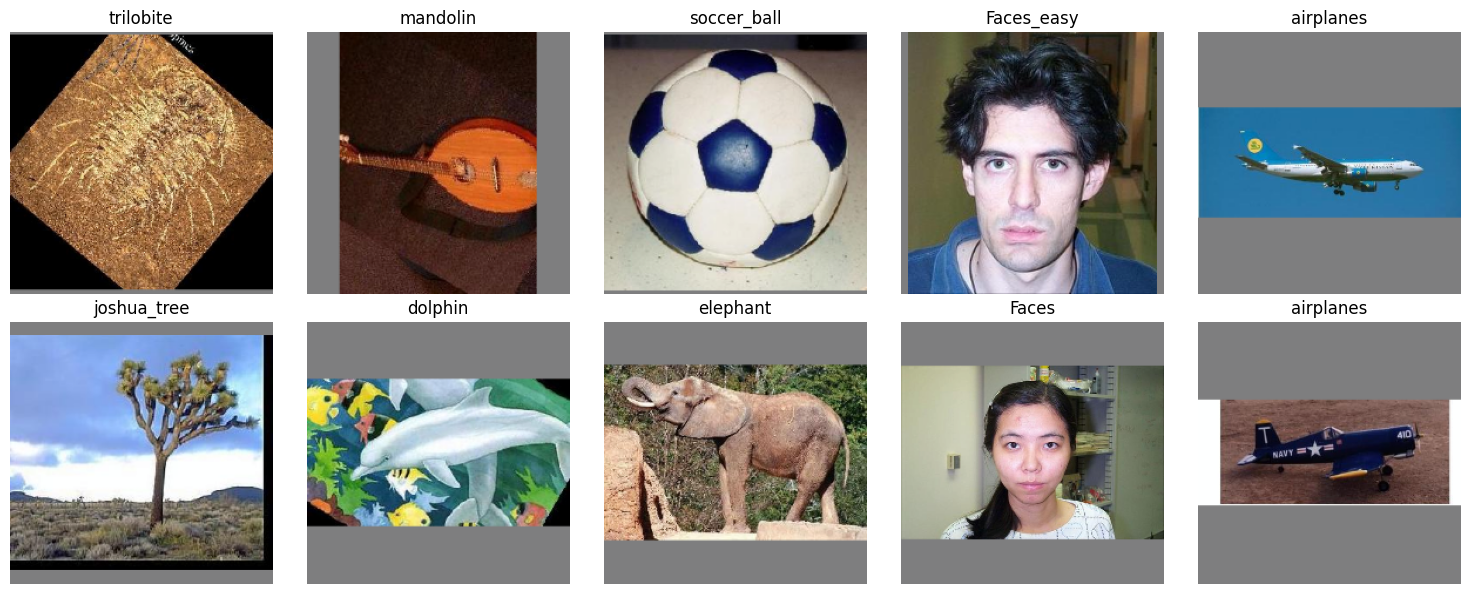

In [7]:
########################################################################################################################
# 6. UČITAVANJE PODATAKA
########################################################################################################################

image_size = 224
batch_size = 32

print("Učitavanje i pretprocesiranje slika...")
categories, train_images, test_images = load_data_def()
print("Broj trening slika:", len(train_images))
print("Broj test slika:", len(test_images))
print("Broj kategorija:", len(categories))

train_dataset = CaltechDataset(train_images, image_size, transform=train_transforms, keep_aspect=True, fill_value=(127, 127, 127))
test_dataset = CaltechDataset(test_images, image_size, transform=None, keep_aspect=True, fill_value=(127, 127, 127))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("\nPrikaz prvih 10 slika iz test skupa...")
plt.figure(figsize=(15, 6))  # Širina i visina prozora za prikaz

# Dohvatanje prvog batch-a iz iteratora
inputs, labels = next(iter(test_loader))

# Parametri sa kojima smo normalizovali slike u base_transform-u
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(10):
    plt.subplot(2, 5, i + 1)  # Kreiranje grida: 2 reda, 5 kolona, i-ta pozicija

    # 1. Konverzija iz tenzora u numpy niz
    img = inputs[i].numpy()
    # 2. Transponovanje iz CHW (C, H, W) u HWC (H, W, C) format koji očekuje plt.imshow
    img = img.transpose((1, 2, 0))
    # 3. Denormalizacija (vraćanje u originalni opseg)
    img = std * img + mean
    # 4. Skaliranje na 0-255 i sečenje viška (clipping) radi izbegavanja anomalija pri zaokruživanju
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    plt.imshow(img)

    # Preuzimanje integer vrednosti iz label tenzora pomoću .item()
    class_index = labels[i].item()
    plt.title(categories[class_index])

    plt.axis('off')  # Isključivanje x i y osa radi preglednijeg prikaza slika

plt.tight_layout()  # Automatsko podešavanje razmaka između slika
plt.show()          # Prikaz grida u Colab ćeliji

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 111MB/s] 



--- Početak Warmup treniranja (20 epoha) ---
Warmup Epoha 01: Loss: 2.4598 | Acc: 0.5077 || Val Loss: 0.9840 | Val Acc: 0.8266
Warmup Epoha 02: Loss: 0.7934 | Acc: 0.8231 || Val Loss: 0.3866 | Val Acc: 0.9171
Warmup Epoha 03: Loss: 0.4918 | Acc: 0.8732 || Val Loss: 0.2942 | Val Acc: 0.9222
Warmup Epoha 04: Loss: 0.3651 | Acc: 0.9006 || Val Loss: 0.2496 | Val Acc: 0.9315
Warmup Epoha 05: Loss: 0.3206 | Acc: 0.9084 || Val Loss: 0.2233 | Val Acc: 0.9355
Warmup Epoha 06: Loss: 0.2621 | Acc: 0.9258 || Val Loss: 0.2057 | Val Acc: 0.9435
Warmup Epoha 07: Loss: 0.2463 | Acc: 0.9311 || Val Loss: 0.1946 | Val Acc: 0.9389
Warmup Epoha 08: Loss: 0.2216 | Acc: 0.9336 || Val Loss: 0.1914 | Val Acc: 0.9430
Warmup Epoha 09: Loss: 0.1876 | Acc: 0.9414 || Val Loss: 0.1816 | Val Acc: 0.9453
Warmup Epoha 10: Loss: 0.1809 | Acc: 0.9487 || Val Loss: 0.1752 | Val Acc: 0.9470
Warmup Epoha 11: Loss: 0.1683 | Acc: 0.9496 || Val Loss: 0.1797 | Val Acc: 0.9453
Warmup Epoha 12: Loss: 0.1605 | Acc: 0.9496 || Val L

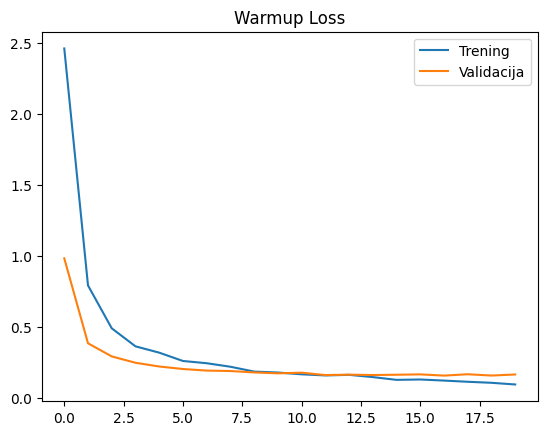

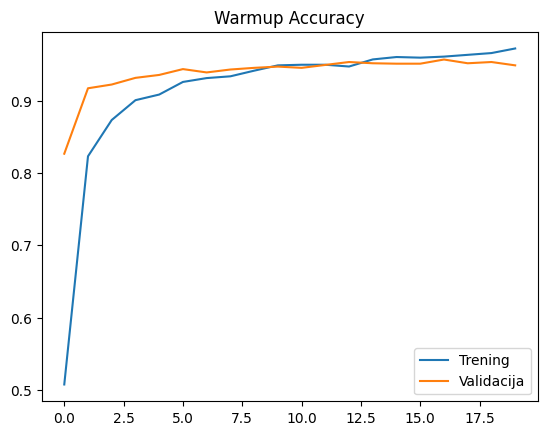

In [8]:
########################################################################################################################
# 7. INICIJALNO OBUČAVANJE MODELA (WARMUP TRAINING)
########################################################################################################################

model = create_model(classes=len(categories), trainable_encoder=False)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

warmup_history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
warmup_csv_path = os.path.join(drive_results_folder, 'warmup.csv')

print("\n--- Početak Warmup treniranja (20 epoha) ---")
epochs_warmup = 20

with open(warmup_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy'])

    for epoch in range(epochs_warmup):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double().item() / len(train_dataset)

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(test_dataset)
        val_epoch_acc = val_corrects.double().item() / len(test_dataset)

        warmup_history['loss'].append(epoch_loss)
        warmup_history['accuracy'].append(epoch_acc)
        warmup_history['val_loss'].append(val_epoch_loss)
        warmup_history['val_accuracy'].append(val_epoch_acc)

        writer.writerow([epoch, epoch_loss, epoch_acc, val_epoch_loss, val_epoch_acc])
        print(f'Warmup Epoha {epoch+1:02d}: Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} || Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}')

# Čuvanje Warmup modela i grafika
torch.save(model.state_dict(), os.path.join(drive_results_folder, 'warmup_model.pth'))

plt.clf()
plt.plot(warmup_history['loss'], label='Trening')
plt.plot(warmup_history['val_loss'], label='Validacija')
plt.legend()
plt.title('Warmup Loss')
plt.savefig(os.path.join(drive_results_folder, 'warmup_loss.png'))
plt.show()

plt.clf()
plt.plot(warmup_history['accuracy'], label='Trening')
plt.plot(warmup_history['val_accuracy'], label='Validacija')
plt.legend()
plt.title('Warmup Accuracy')
plt.savefig(os.path.join(drive_results_folder, 'warmup_accuracy.png'))
plt.show()


--- Početak Fine-tuning treniranja ---
Fine-tune Epoch 001: Loss: 0.1141 | Acc: 0.9643 || Val Loss: 0.1728 | Val Acc: 0.9482 || LR: 0.00010000
Fine-tune Epoch 002: Loss: 0.1085 | Acc: 0.9674 || Val Loss: 0.1521 | Val Acc: 0.9528 || LR: 0.00010000
Fine-tune Epoch 003: Loss: 0.0803 | Acc: 0.9738 || Val Loss: 0.1676 | Val Acc: 0.9499 || LR: 0.00010000
Fine-tune Epoch 004: Loss: 0.0787 | Acc: 0.9762 || Val Loss: 0.1633 | Val Acc: 0.9556 || LR: 0.00010000
Fine-tune Epoch 005: Loss: 0.0581 | Acc: 0.9823 || Val Loss: 0.1588 | Val Acc: 0.9556 || LR: 0.00010000
Fine-tune Epoch 006: Loss: 0.0596 | Acc: 0.9821 || Val Loss: 0.1680 | Val Acc: 0.9522 || LR: 0.00010000
Fine-tune Epoch 007: Loss: 0.0557 | Acc: 0.9827 || Val Loss: 0.1754 | Val Acc: 0.9505 || LR: 0.00010000
Fine-tune Epoch 008: Loss: 0.0545 | Acc: 0.9826 || Val Loss: 0.1682 | Val Acc: 0.9545 || LR: 0.00010000
Fine-tune Epoch 009: Loss: 0.0524 | Acc: 0.9840 || Val Loss: 0.1676 | Val Acc: 0.9545 || LR: 0.00010000
Fine-tune Epoch 010: Los

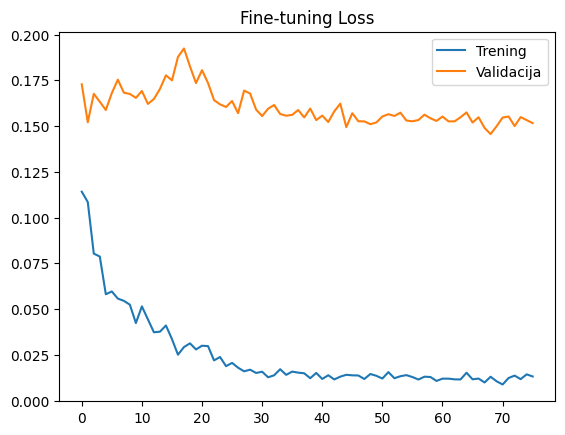

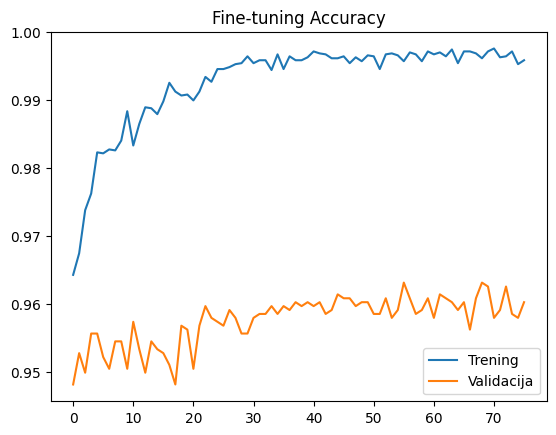

In [9]:
########################################################################################################################
# 8. FINO OBUČAVANJE MODELA (FINE-TUNING)
########################################################################################################################

print("\n--- Početak Fine-tuning treniranja ---")

# Otključavanje svih slojeva
for param in model.parameters():
    param.requires_grad = True

# Novo postavljanje optimizatora i scheduler-a sa smanjenom stopom učenja
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10)

fine_history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
finetune_csv_path = os.path.join(drive_results_folder, 'finetuning.csv')

epochs_finetune = 1000
early_stopping_patience = 20
epochs_no_improve = 0
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

with open(finetune_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

    for epoch in range(epochs_finetune):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double().item() / len(train_dataset)

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(test_dataset)
        val_epoch_acc = val_corrects.double().item() / len(test_dataset)

        fine_history['loss'].append(epoch_loss)
        fine_history['accuracy'].append(epoch_acc)
        fine_history['val_loss'].append(val_epoch_loss)
        fine_history['val_accuracy'].append(val_epoch_acc)

        current_lr = optimizer.param_groups[0]['lr']
        writer.writerow([epoch, epoch_loss, epoch_acc, val_epoch_loss, val_epoch_acc, current_lr])
        print(f'Fine-tune Epoch {epoch+1:03d}: Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} || Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f} || LR: {current_lr:.8f}')

        scheduler.step(val_epoch_acc)

        # Early stopping
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stopping_patience:
                print(f"Rano zaustavljanje (Early stopping) pokrenuto nakon epohe {epoch+1}")
                break

# Učitavanje najboljih težina
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(drive_results_folder, 'finetuned_model.pth'))

plt.clf()
plt.plot(fine_history['loss'], label='Trening')
plt.plot(fine_history['val_loss'], label='Validacija')
plt.legend()
plt.title('Fine-tuning Loss')
plt.savefig(os.path.join(drive_results_folder, 'finetuning_loss.png'))
plt.show()

plt.clf()
plt.plot(fine_history['accuracy'], label='Trening')
plt.plot(fine_history['val_accuracy'], label='Validacija')
plt.legend()
plt.title('Fine-tuning Accuracy')
plt.savefig(os.path.join(drive_results_folder, 'finetuning_accuracy.png'))
plt.show()


Evaluacija modela na trening skupu (bez augmentacije)...
Finalna trening tačnost (bez augmentacije): 0.9994

Evaluacija modela i sakupljanje predikcija na test skupu...
Finalna test tačnost: 0.9631

Pogrešne predikcije (64 komada) su sačuvane na Drive-u u folderu: /content/drive/MyDrive/Caltech101_v2_Results_PyTorch/misclassified

Prikaz prvih (do 25) loše klasifikovanih slika:


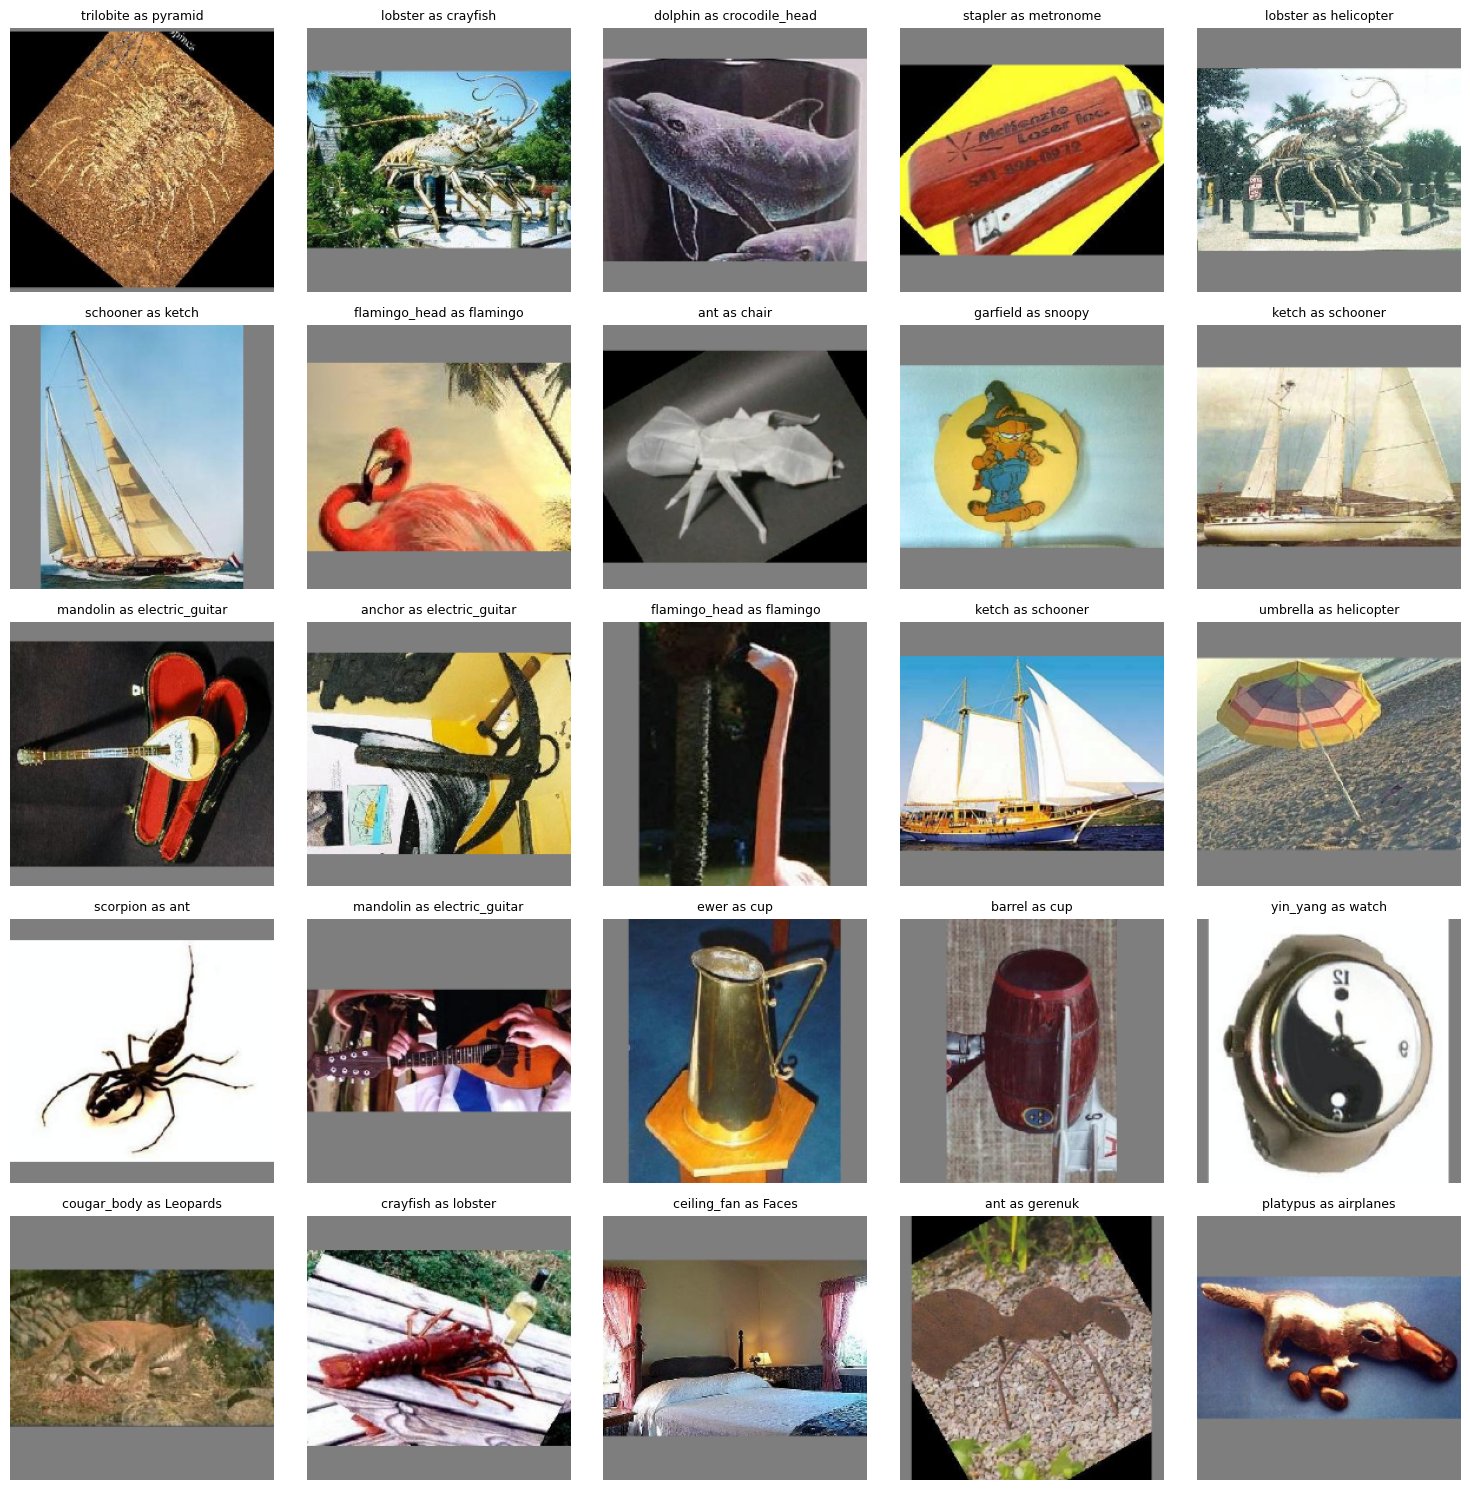

In [10]:
########################################################################################################################
# 9. EVALUACIJA MODELA
########################################################################################################################

print("\nEvaluacija modela na trening skupu (bez augmentacije)...")

# Kreiramo poseban dataset i loader za trening podatke BEZ augmentacije
train_dataset_eval = CaltechDataset(train_images, image_size, transform=None, keep_aspect=True)
train_loader_eval = DataLoader(train_dataset_eval, batch_size=batch_size, shuffle=False, num_workers=2)

model.eval()
train_corrects = 0

with torch.no_grad():
    for inputs, labels in train_loader_eval:
        inputs_device = inputs.to(device)
        labels_device = labels.to(device)

        outputs = model(inputs_device)
        _, preds = torch.max(outputs, 1)

        train_corrects += torch.sum(preds == labels_device.data)

train_accuracy = train_corrects.double().item() / len(train_dataset_eval)
print(f"Finalna trening tačnost (bez augmentacije): {train_accuracy:.4f}")

# Evaluacija na test skupu i nalaženje loše klasifikovanih slika
print("\nEvaluacija modela i sakupljanje predikcija na test skupu...")
model.eval()

all_preds = []
all_labels = []

misclassified_folder = os.path.join(drive_results_folder, 'misclassified')
if not os.path.exists(misclassified_folder):
    os.makedirs(misclassified_folder)

i = 0
misclassified_for_grid = []

# Parametri za denormalizaciju slika (ImageNet standard iz base_transform-a)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_device = inputs.to(device)
        outputs = model(inputs_device)
        _, preds = torch.max(outputs, 1)

        # Prebacivanje nazad na CPU i u numpy format za evaluaciju
        preds_np = preds.cpu().numpy()
        labels_np = labels.numpy()
        inputs_np = inputs.numpy() # Originalni PyTorch tenzori iz batch-a

        all_preds.extend(preds_np)
        all_labels.extend(labels_np)

        # Prolazak kroz trenutni batch i traženje grešaka u hodu
        for j in range(len(preds_np)):
            out = preds_np[j]
            exp = labels_np[j]

            if out != exp:
                i += 1
                title = '{} as {}'.format(categories[int(exp)], categories[int(out)])

                # Denormalizacija tenzora za vizuelizaciju:
                # 1. Konverzija iz CHW u HWC format
                img = inputs_np[j].transpose((1, 2, 0))
                # 2. Vraćanje originalnog opsega boja (oduzimanje mean i deljenje sa std smo obrnuli)
                img = std * img + mean
                # 3. Odsecanje viška (clipping) i konverzija u uint8 za ispravan prikaz slike
                img = np.clip(img * 255, 0, 255).astype(np.uint8)

                # Čuvanje svake pogrešne slike na disk
                plt.figure(figsize=(4, 4))
                plt.imshow(img)
                plt.title(title)
                plt.savefig(os.path.join(misclassified_folder, '{} ({}).jpg'.format(i, title)))
                plt.close()

                # Zadržavanje prvih 25 za grid prikaz u Colab-u
                if len(misclassified_for_grid) < 25:
                    misclassified_for_grid.append((img, title))

y_out = np.array(all_preds)
y_test_flat = np.array(all_labels)

# Izračunavanje finalne test tačnosti na osnovu sakupljenih listi
test_accuracy = np.sum(y_out == y_test_flat) / len(y_test_flat)
print(f"Finalna test tačnost: {test_accuracy:.4f}")

print(f"\nPogrešne predikcije ({i} komada) su sačuvane na Drive-u u folderu: {misclassified_folder}")

# Prikaz prvih 25 pogrešnih predikcija u gridu
if misclassified_for_grid:
    print("\nPrikaz prvih (do 25) loše klasifikovanih slika:")
    cols = 5
    rows = min(5, (len(misclassified_for_grid) + cols - 1) // cols)

    plt.figure(figsize=(15, 3 * rows))
    for idx, (img, title) in enumerate(misclassified_for_grid):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(title, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()